In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/poojashree81/breast-cancer-wisconsin/wdbc.names
/kaggle/input/datasets/poojashree81/breast-cancer-wisconsin/wdbc.data


# Cell 1 — Import Libraries

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Cell 2 — Plot Formatting

In [3]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'savefig.dpi': 600,
})

sns.set(style="whitegrid")

def set_plot_style():
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 12,
        'axes.labelweight': 'bold',
        'axes.titleweight': 'bold',
        'axes.labelsize': 13,
        'axes.titlesize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'savefig.dpi': 600,
    })

def save_current_plot(name, folder="figures", close=False):
    os.makedirs(folder, exist_ok=True)
    safe_name = re.sub(r'[^A-Za-z0-9_\-]+', '_', str(name)).strip('_')
    fig = plt.gcf()
    path = os.path.join(folder, f"{safe_name}.eps")
    fig.savefig(path, format="eps", dpi=600, bbox_inches="tight")
    print(f"Saved: {path}")
    if close:
        plt.close(fig)
    return path

# Cell 3 — Load Dataset

In [4]:
data_path = "/kaggle/input/datasets/poojashree81/breast-cancer-wisconsin/wdbc.data"

columns = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df = pd.read_csv(
    data_path,
    header=None,
    names=columns
)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  

# Cell 4 — Encode Class Labels

In [5]:
X = df.drop(columns=["id", "diagnosis"])

y = df["diagnosis"].map({
    "M": "Malignant",
    "B": "Benign"
})

print("Features:", X.shape)
print("\nClass Distribution:")
print(y.value_counts())

Features: (569, 30)

Class Distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


# Cell 5 — Basic Dataset Information

In [6]:
print(X.head())
print("\nDataset Information:")
print(X.info())

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave_points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

# Cell 6 — Class Distribution

Saved: figures/class_distribution.eps


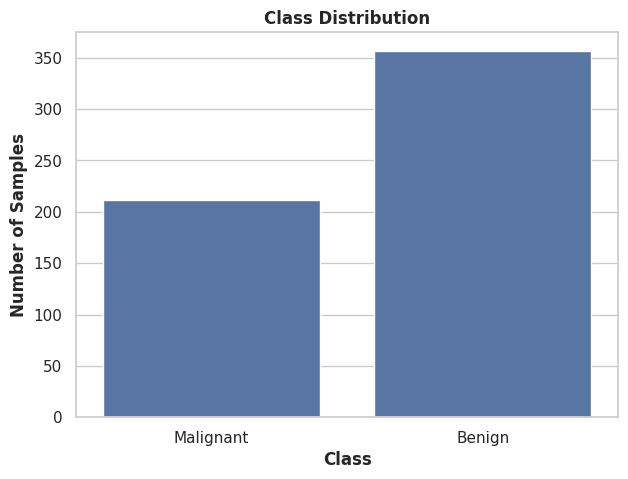

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

save_current_plot("class_distribution")
plt.show()

# Cell 7 — Feature Correlation Analysis

Saved: figures/feature_correlation.eps


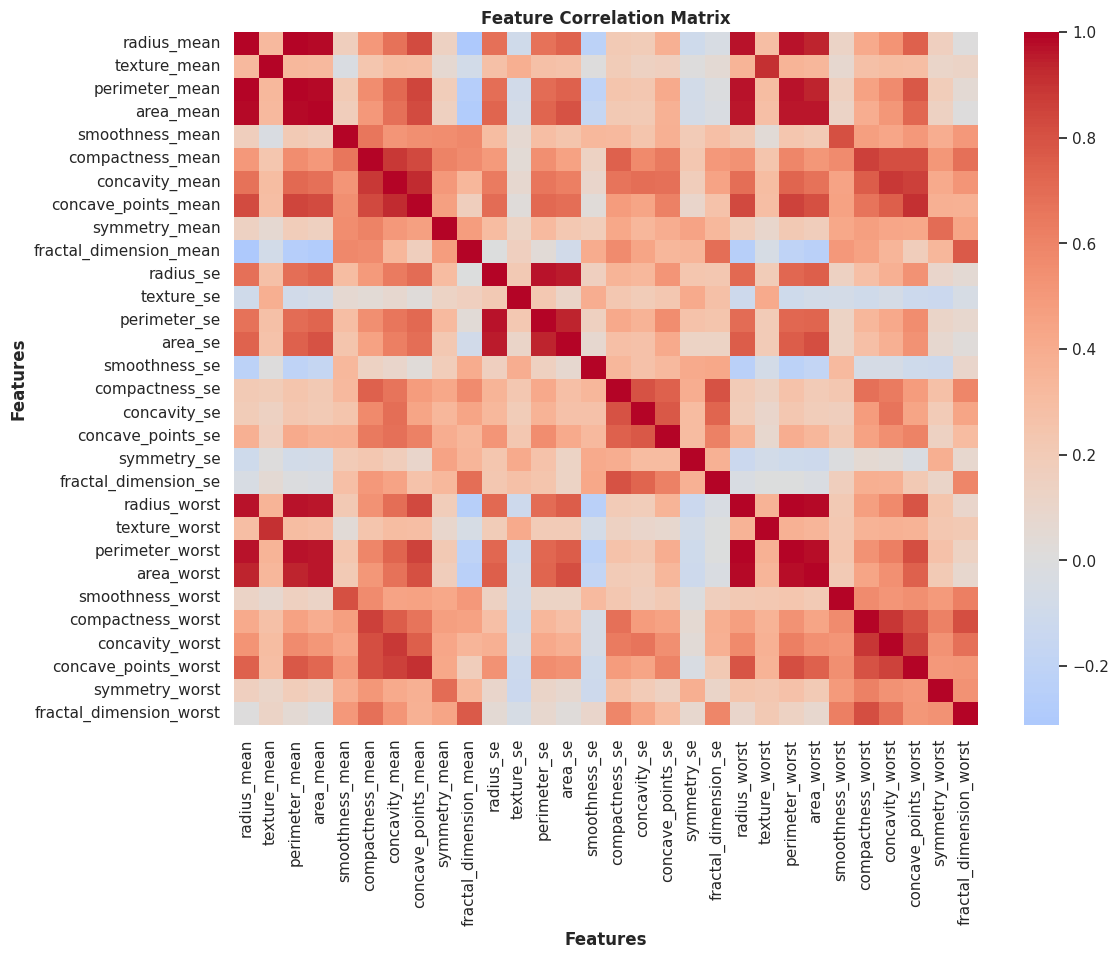

In [8]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")

save_current_plot("feature_correlation")
plt.show()

# Cell 8 — Split Dataset

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


# Cell 9 — Basic Decision Tree

In [10]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9298245614035088


# Cell 10 — Decision Tree Hyperparameter Search

In [11]:
dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=cv,
    scoring="accuracy"
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest CV Accuracy:")
print(dt_grid.best_score_)

Best Decision Tree Parameters:
{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best CV Accuracy:
0.9296703296703297


# Cell 11 — Best Decision Tree

In [12]:
best_dt = dt_grid.best_estimator_

best_dt.fit(X_train, y_train)

y_pred_dt = best_dt.predict(X_test)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Test F1 Score:",
      f1_score(y_test, y_pred_dt, pos_label="Malignant"))

Test Accuracy: 0.9385964912280702
Test F1 Score: 0.9135802469135802


# Cell 12 — Decision Tree CV Results

In [13]:
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_results = dt_results[
    [
        "param_criterion",
        "param_max_depth",
        "mean_test_score"
    ]
]

dt_results.columns = [
    "Criterion",
    "Max Depth",
    "Avg CV Accuracy"
]

dt_results["Avg CV Accuracy"] = dt_results["Avg CV Accuracy"] * 100

print(dt_results.head(10))

  Criterion  Max Depth  Avg CV Accuracy
0      gini          3        92.087912
1      gini          3        92.087912
2      gini          3        92.087912
3      gini          3        92.087912
4      gini          5        90.769231
5      gini          5        91.208791
6      gini          5        92.087912
7      gini          5        92.087912
8      gini          7        92.307692
9      gini          7        92.307692


# Cell 13 — Basic Random Forest

In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9736842105263158


# Cell 14 — Random Forest Hyperparameter Search

In [15]:
rf_params = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 10],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=cv,
    scoring="accuracy"
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV Accuracy:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}

Best CV Accuracy:
0.9714285714285715


# Cell 15 — Best Random Forest

In [16]:
best_rf = rf_grid.best_estimator_

best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_test)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Test F1 Score:",
      f1_score(y_test, y_pred_rf, pos_label="Malignant"))

Test Accuracy: 0.9649122807017544
Test F1 Score: 0.95


# Cell 16 — Random Forest CV Results

In [17]:
rf_results = pd.DataFrame(rf_grid.cv_results_)

rf_results = rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_max_features",
        "param_bootstrap",
        "mean_test_score"
    ]
]

rf_results.columns = [
    "n estimators",
    "Max Depth",
    "Max Features",
    "Bootstrap",
    "Avg CV Accuracy"
]

rf_results["Avg CV Accuracy"] = rf_results["Avg CV Accuracy"] * 100

print(rf_results.head(10))

   n estimators  Max Depth Max Features  Bootstrap  Avg CV Accuracy
0            50          3         sqrt       True        95.824176
1           100          3         sqrt       True        95.604396
2            50          3         log2       True        95.384615
3           100          3         log2       True        95.824176
4            50          5         sqrt       True        96.263736
5           100          5         sqrt       True        96.703297
6            50          5         log2       True        95.824176
7           100          5         log2       True        96.043956
8            50         10         sqrt       True        96.043956
9           100         10         sqrt       True        96.483516


# Cell 17 — Fold-wise Accuracy

In [18]:
dt_fold_scores = cross_val_score(
    best_dt,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

rf_fold_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

comparison = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Decision Tree": dt_fold_scores,
    "Random Forest": rf_fold_scores
})

comparison.loc[len(comparison)] = [
    "Average",
    dt_fold_scores.mean(),
    rf_fold_scores.mean()
]

print(comparison)

      Fold  Decision Tree  Random Forest
0        1       0.901099       0.967033
1        2       0.967033       0.989011
2        3       0.901099       0.967033
3        4       0.923077       0.956044
4        5       0.956044       0.978022
5  Average       0.929670       0.971429


# Cell 18 — Cross-Validation Comparison Visualization

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/5_fold_cv_comparison.eps


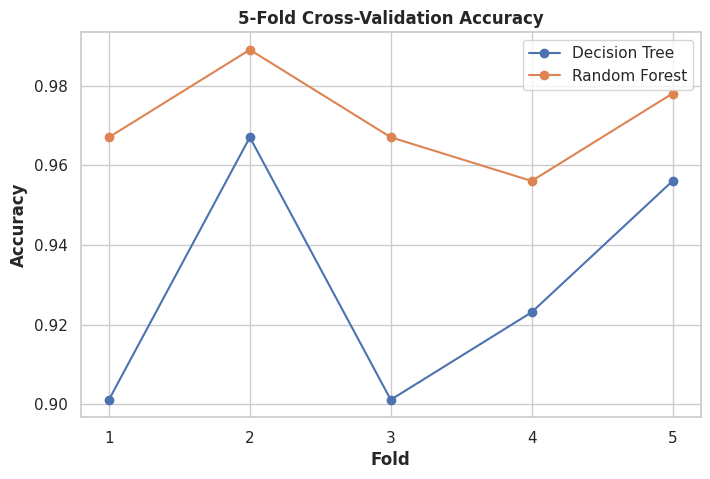

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    dt_fold_scores,
    marker="o",
    label="Decision Tree"
)

plt.plot(
    range(1, 6),
    rf_fold_scores,
    marker="o",
    label="Random Forest"
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.legend()

save_current_plot("5_fold_cv_comparison")
plt.show()

# Cell 19 — Decision Tree Metrics

In [20]:
print("Decision Tree")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, pos_label="Malignant"))
print("Recall   :", recall_score(y_test, y_pred_dt, pos_label="Malignant"))
print("F1 Score :", f1_score(y_test, y_pred_dt, pos_label="Malignant"))

Decision Tree
Accuracy : 0.9385964912280702
Precision: 0.9487179487179487
Recall   : 0.8809523809523809
F1 Score : 0.9135802469135802


# Cell 20 — Random Forest Metrics

In [21]:
print("Random Forest")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="Malignant"))
print("Recall   :", recall_score(y_test, y_pred_rf, pos_label="Malignant"))
print("F1 Score :", f1_score(y_test, y_pred_rf, pos_label="Malignant"))

Random Forest
Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9047619047619048
F1 Score : 0.95


# Cell 21 — Compare Both Models

In [22]:
metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt, pos_label="Malignant"),
        recall_score(y_test, y_pred_dt, pos_label="Malignant"),
        f1_score(y_test, y_pred_dt, pos_label="Malignant")
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, pos_label="Malignant"),
        recall_score(y_test, y_pred_rf, pos_label="Malignant"),
        f1_score(y_test, y_pred_rf, pos_label="Malignant")
    ]
})

print(metrics)

      Metric  Decision Tree  Random Forest
0   Accuracy       0.938596       0.964912
1  Precision       0.948718       1.000000
2     Recall       0.880952       0.904762
3   F1 Score       0.913580       0.950000


# Cell 22 — Metric Visualization

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/model_metric_comparison.eps


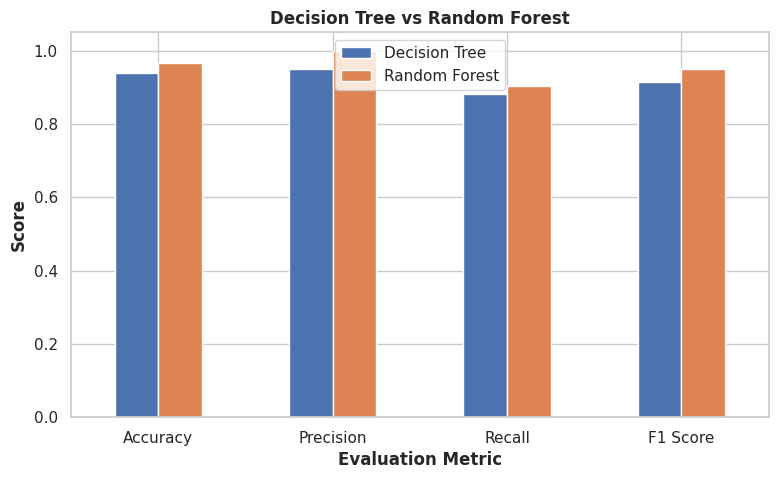

In [23]:
metrics_plot = metrics.set_index("Metric")

metrics_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Decision Tree vs Random Forest")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()

save_current_plot("model_metric_comparison")
plt.show()

# Cell 23 Confusion Matrix — Decision Tree

Saved: figures/decision_tree_confusion_matrix.eps


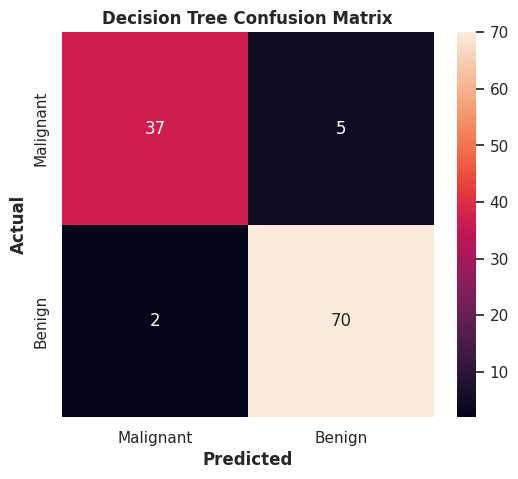

In [24]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt,
    labels=["Malignant", "Benign"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

save_current_plot("decision_tree_confusion_matrix")
plt.show()

# Cell 24 Confusion Matrix — Random Forest

Saved: figures/random_forest_confusion_matrix.eps


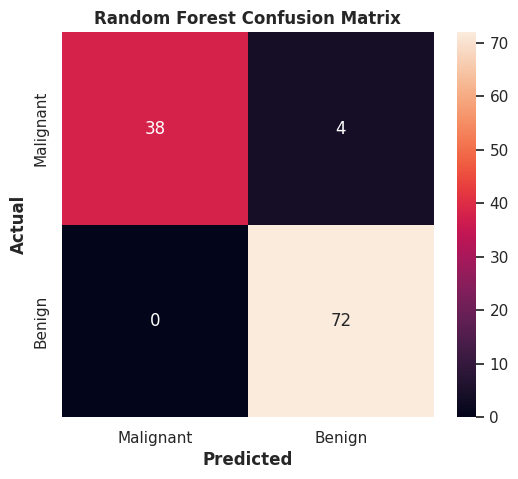

In [25]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Malignant", "Benign"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

save_current_plot("random_forest_confusion_matrix")
plt.show()

# Cell 25 — ROC Curve

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/roc_curve.eps


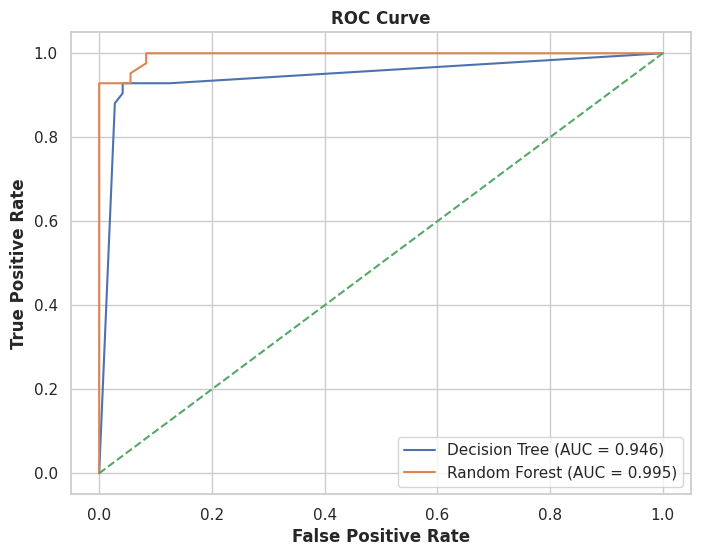

Decision Tree AUC: 0.9457671957671958
Random Forest AUC: 0.9950396825396826


In [26]:
y_test_binary = y_test.map({
    "Benign": 0,
    "Malignant": 1
})

# Probability of Malignant
dt_prob = best_dt.predict_proba(X_test)[:, 1]
rf_prob = best_rf.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test_binary, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test_binary, rf_prob)

auc_dt = roc_auc_score(y_test_binary, dt_prob)
auc_rf = roc_auc_score(y_test_binary, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {auc_dt:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

save_current_plot("roc_curve")
plt.show()

print("Decision Tree AUC:", auc_dt)
print("Random Forest AUC:", auc_rf)

# Cell 26 Final Comparison Table

In [27]:
final_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt, pos_label="Malignant"),
        precision_score(y_test, y_pred_rf, pos_label="Malignant")
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt, pos_label="Malignant"),
        recall_score(y_test, y_pred_rf, pos_label="Malignant")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_dt, pos_label="Malignant"),
        f1_score(y_test, y_pred_rf, pos_label="Malignant")
    ],
    "AUC": [
        auc_dt,
        auc_rf
    ]
})

print(final_results)

           Model  Accuracy  Precision    Recall  F1 Score       AUC
0  Decision Tree  0.938596   0.948718  0.880952   0.91358  0.945767
1  Random Forest  0.964912   1.000000  0.904762   0.95000  0.995040


# Cell 27 — Display Final Results as Percentage

In [28]:
final_percentage = final_results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]:
    final_percentage[column] = (
        final_percentage[column] * 100
    ).round(2)

print(final_percentage)

           Model  Accuracy  Precision  Recall  F1 Score    AUC
0  Decision Tree     93.86      94.87   88.10     91.36  94.58
1  Random Forest     96.49     100.00   90.48     95.00  99.50


In [29]:
!zip -r output.zip /kaggle/working/figures

  adding: kaggle/working/figures/ (stored 0%)
  adding: kaggle/working/figures/5_fold_cv_comparison.eps (deflated 66%)
  adding: kaggle/working/figures/decision_tree_confusion_matrix.eps (deflated 99%)
  adding: kaggle/working/figures/roc_curve.eps (deflated 65%)
  adding: kaggle/working/figures/class_distribution.eps (deflated 64%)
  adding: kaggle/working/figures/feature_correlation.eps (deflated 99%)
  adding: kaggle/working/figures/model_metric_comparison.eps (deflated 65%)
  adding: kaggle/working/figures/random_forest_confusion_matrix.eps (deflated 99%)
